In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from plot_openloop import plot_openloop
from plot_estimator import plot_estimator

\begin{align}
    \dot p = \bar\beta(1+x)(1-p)p - \delta p\\
    \tau_x\dot x = -x + \tanh\left((k_p p + k_x x^2 + u_0)x\right)
\end{align}

define the dynamics:

In [ ]:
def SIS_NOD(t, y, beta,delta,kp,kx,u0,tau,w):
    p = max(0, min(1, y[0])) # keep everything bounded
    x = max(-1, min(1, y[1]))
    pdot = beta*(1+x)*(1-p)*p - delta*p
    xdot = (-x +np.tanh((kp*p + kx*x*x + u0)*x)+w)/tau

    return [pdot,xdot] 

Define parameters, initial condition, bifurcation points (from theory and numerical continuation), run a simulation without noise to make sure everything works:

In [116]:
delta = 0.3
kp = 0.7
kx = 0.3
u0 = 0.7
tau = 1
w = 0

betastar = delta*kp/(kp-1+u0)

# bifurcation points
bp1 = delta
bp2 = 0.36974549
bp3 = betastar

print(bp1,bp2,bp3)

0.3 0.36974549 0.5250000000000001


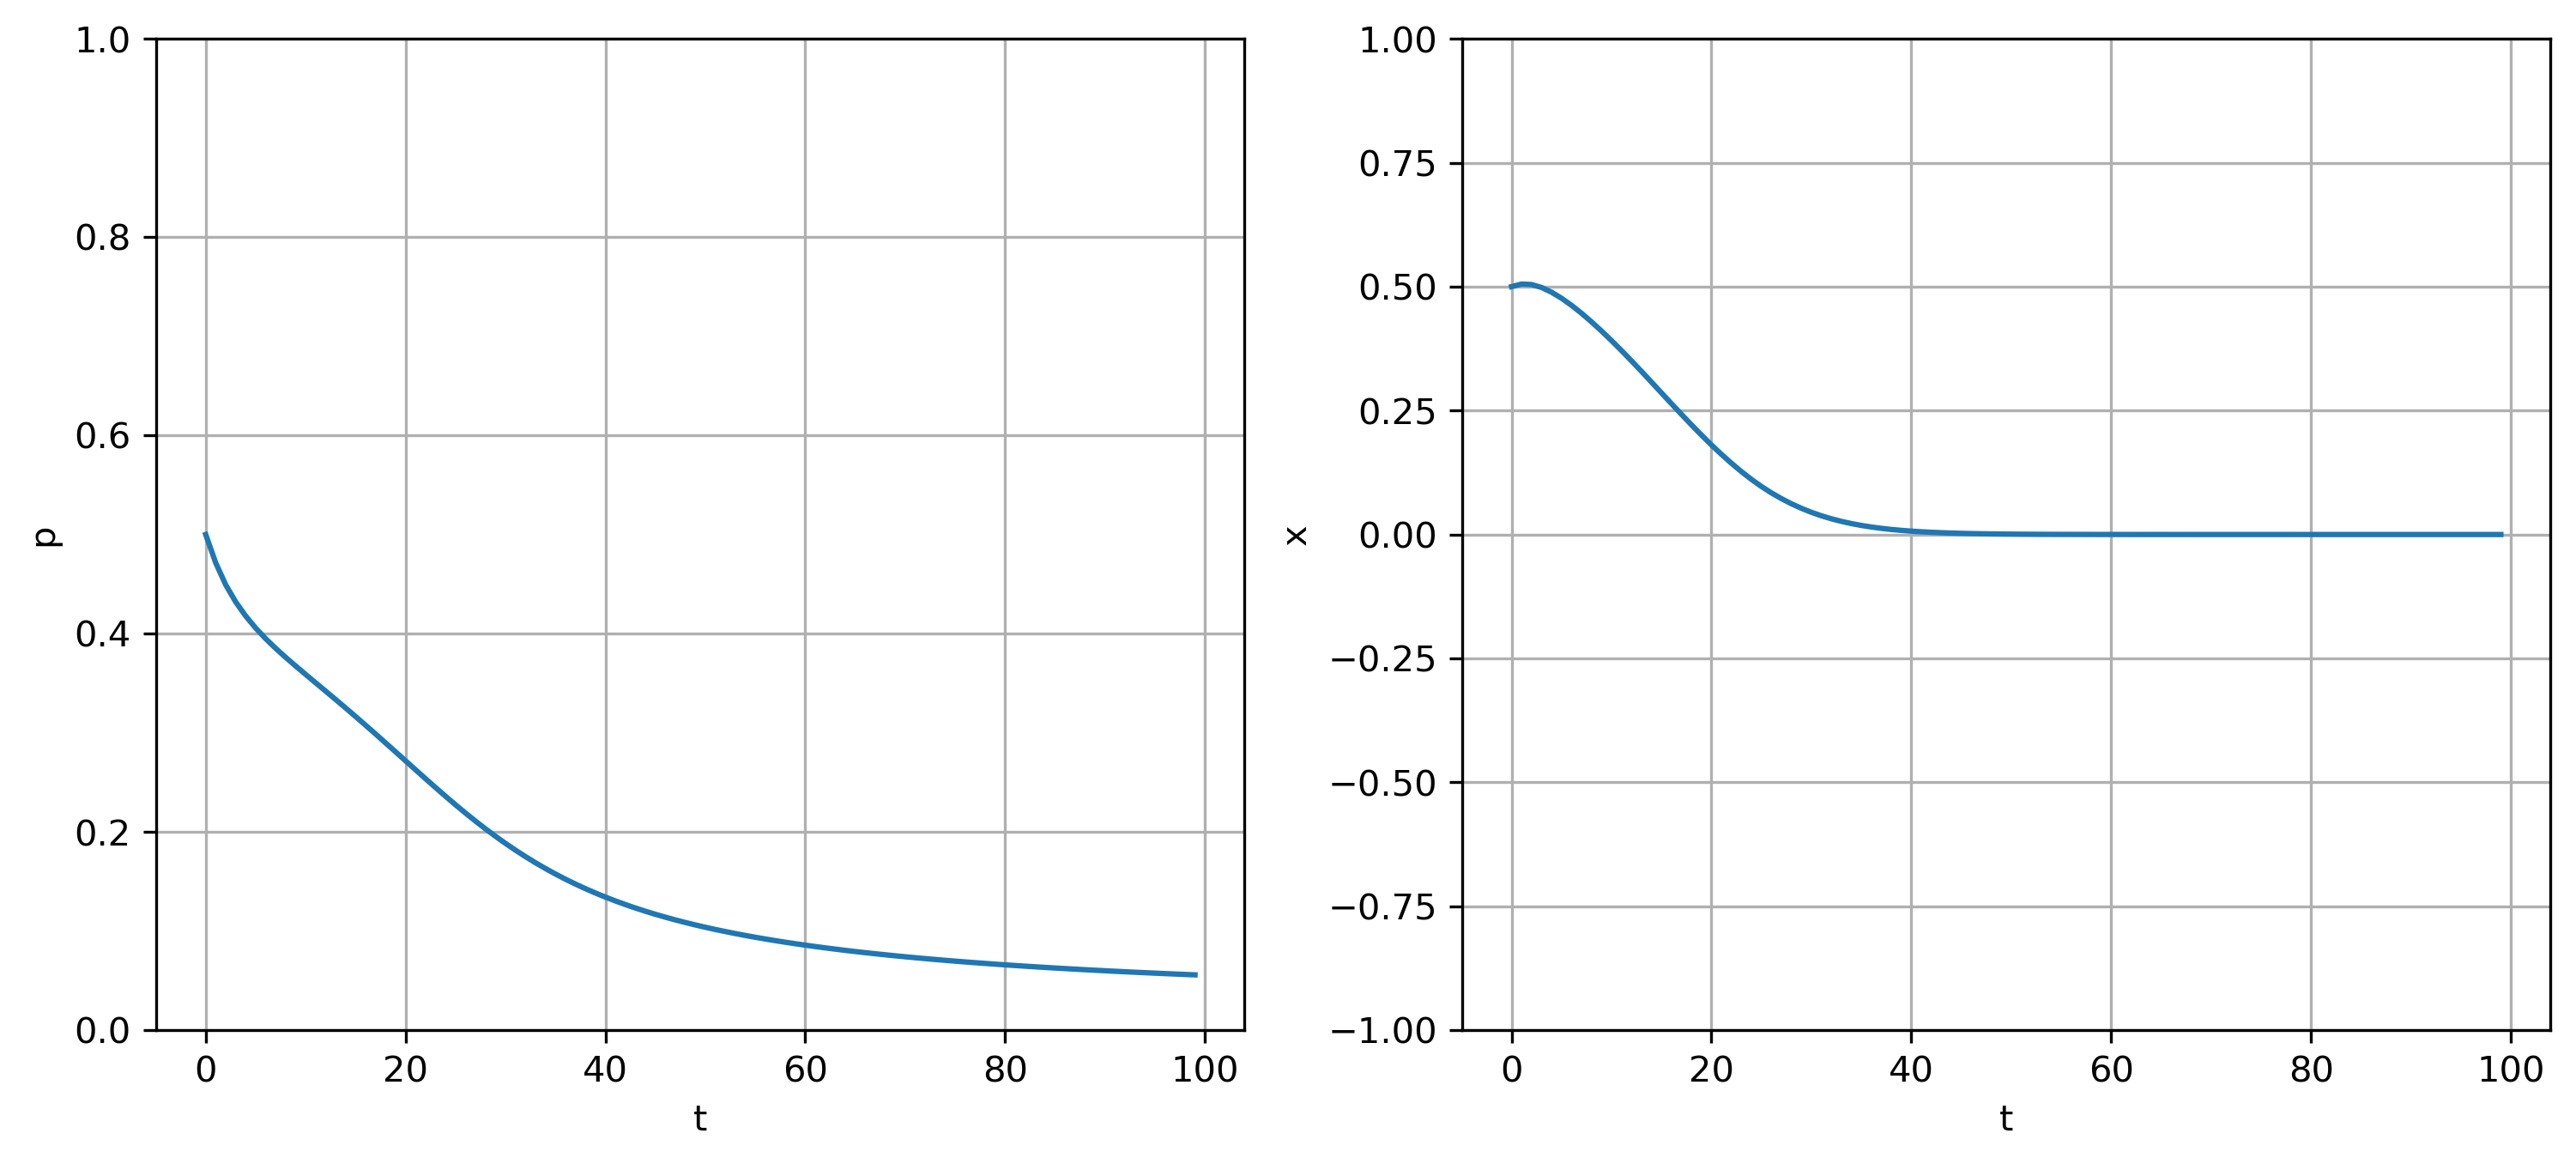

In [117]:
beta = 0.31

y0 = [0.5,0.5]

tspan = [0,100]
dt = 1.0
t_eval = np.arange(tspan[0],tspan[1],dt)
sol = solve_ivp(SIS_NOD,tspan,y0,args = (beta,delta,kp,kx,u0,tau,w),t_eval = t_eval,method = "LSODA")

fig,ax = plt.subplots(1,2,figsize = (12,5),dpi = 300)
ax[0].plot(sol.t,sol.y[0])
ax[0].set_xlabel("t")
ax[0].set_ylabel("p")
ax[0].set_ylim(0,1)
ax[0].grid()

ax[1].plot(sol.t,sol.y[1])
ax[1].set_xlabel("t")
ax[1].set_ylabel("x")
ax[1].set_ylim(-1,1)
ax[1].grid()

plt.show()

In [118]:
def predict_state_SIS_NOD(Xk, Wk, mu, dt):
    nx, N = Xk.shape
    Xkp1 = np.zeros_like(Xk)

    for i in range(N):
        x0 = Xk[:, i]
        w  = Wk[0, i]
        
        sol = solve_ivp(
            SIS_NOD,
            [0, dt],
            x0,
            args=(mu, w),
            method='LSODA'
        )

        Xkp1[:, i] = sol.y[:, -1]

    return Xkp1



def predict_msmt_vdp(Xkp1):
    """
    """
    H = np.array([[1, 0]])
    return H @ Xkp1  # (1 x nsp)

generate measurements

In [119]:
np.std(w)

np.float64(0.0)

In [121]:
#rng = np.random.default_rng(10)
t = t_eval
tf = t[-1]
nt = len(t)

# Process noise

wstd = 0.02
Qc = wstd**2 # sqrt of this is std of w
w = rng.standard_normal(nt) * (np.sqrt(Qc) / np.sqrt(dt))
Qd = Qc / dt
G = np.array([[0.0], [dt]])

# Simulate Van der Pol via solve_ivp (ode45 equivalent)
y0 = [0.5,0.5]
ny = 2
y_true = np.zeros((ny, nt))
y_true[:, 0] = y0

for k in range(nt - 1):
    y_init = y_true[:, k]
    wk = w[k]
    tspan_small = [t[k], t[k + 1]]
    sol = solve_ivp(SIS_NOD, tspan_small, y_init, args=(beta,delta,kp,kx,u0,tau,wk), method='LSODA')
    y_true[:, k + 1] = sol.y[:, -1]

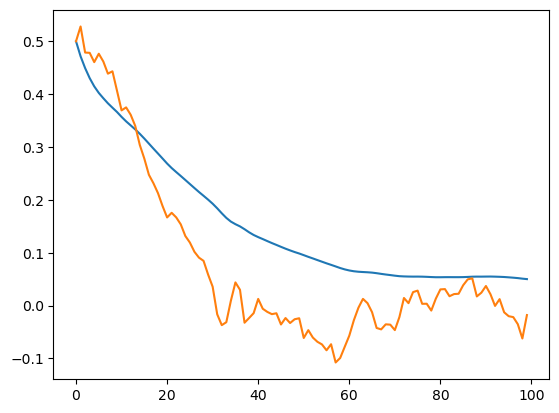

In [122]:
plt.plot(y_true[0])
plt.plot(y_true[1])
plt.show()

In [ ]:
H = np.array([[1, 0]])

N_part = 500
Neff_thresh = int(N_part//2)
X_part = np.zeros((2,N_part,nt))
X_part[:, :, 0] = rng.multivariate_normal(x0, P0, N_part).T